In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the Chinook database
conn = sqlite3.connect("chinook.db")

# SQL Query
query = """
SELECT
    Genre.Name AS Genre,
    COUNT(Track.TrackId) AS Total_Tracks
FROM Track
JOIN Genre
ON Track.GenreId = Genre.GenreId
GROUP BY Genre.Name
ORDER BY Total_Tracks DESC
LIMIT 10;
"""

# Execute query and store result in DataFrame
df = pd.read_sql_query(query, conn)

# Close connection
conn.close()

# Display results
print(df)

# Bar Plot
plt.figure(figsize=(10,6))
plt.bar(df["Genre"], df["Total_Tracks"], color="skyblue")
plt.title("Top 10 Genres with the Highest Number of Tracks")
plt.xlabel("Genre")
plt.ylabel("Number of Tracks")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

DatabaseError: Execution failed on sql '
SELECT
    Genre.Name AS Genre,
    COUNT(Track.TrackId) AS Total_Tracks
FROM Track
JOIN Genre
ON Track.GenreId = Genre.GenreId
GROUP BY Genre.Name
ORDER BY Total_Tracks DESC
LIMIT 10;
': no such column: Track.TrackId

In [2]:
import sqlite3

conn = sqlite3.connect("chinook.db")
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())

conn.close()

[('album',), ('artist',), ('customer',), ('employee',), ('genre',), ('invoice',), ('invoice_line',), ('media_type',), ('playlist',), ('playlist_track',), ('track',), ('wishlist_track',), ('wishlist',)]


                Genre  Total_Tracks
0                Rock          1297
1               Latin           579
2               Metal           374
3  Alternative & Punk           332
4                Jazz           130
5            TV Shows            93
6               Blues            81
7           Classical            74
8               Drama            64
9            R&B/Soul            61


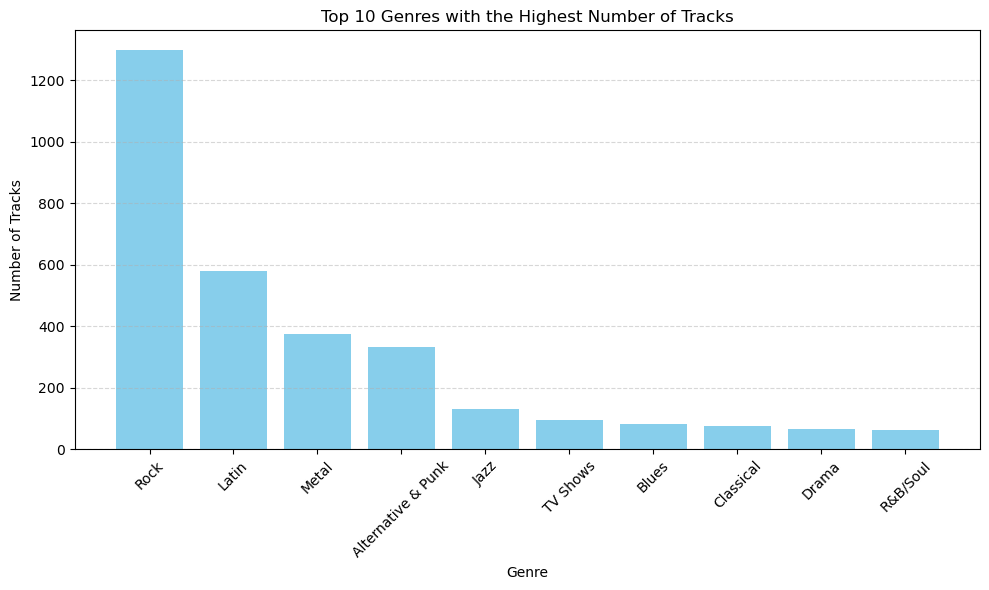

In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the database
conn = sqlite3.connect("chinook.db")

# SQL query
query = """
SELECT
    genre.name AS Genre,
    COUNT(track.track_id) AS Total_Tracks
FROM track
JOIN genre
    ON track.genre_id = genre.genre_id
GROUP BY genre.name
ORDER BY Total_Tracks DESC
LIMIT 10;
"""

# Execute the query
df = pd.read_sql_query(query, conn)

# Close the connection
conn.close()

# Display the result
print(df)

# Plot the result
plt.figure(figsize=(10,6))
plt.bar(df["Genre"], df["Total_Tracks"], color="skyblue")
plt.title("Top 10 Genres with the Highest Number of Tracks")
plt.xlabel("Genre")
plt.ylabel("Number of Tracks")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [10]:
import sqlite3

conn = sqlite3.connect("chinook.db")
cursor = conn.cursor()

query = """
SELECT
    album.title,
    COUNT(track.track_id) AS TotalTracks
FROM album
JOIN track
ON album.album_id = track.album_id
GROUP BY album.album_id, album.title
ORDER BY TotalTracks DESC
LIMIT 10;
"""

cursor.execute(query)

rows = cursor.fetchall()

for row in rows:
    print(row)

conn.close()

('Greatest Hits', 57)
('Minha Historia', 34)
('Unplugged', 30)
('Lost, Season 3', 26)
('Lost, Season 1', 25)
('The Office, Season 3', 25)
('My Way: The Best Of Frank Sinatra [Disc 1]', 24)
('Lost, Season 2', 24)
('Battlestar Galactica (Classic), Season 1', 24)
('Afrociberdelia', 23)


In [20]:
import sqlite3

conn = sqlite3.connect("chinook.db")
cursor = conn.cursor()

cursor.execute("""
SELECT first_name, last_name, city
FROM customer;
""")

rows = cursor.fetchall()

for row in rows:
    print(row)

conn.close()

('Luís', 'Gonçalves', 'São José dos Campos')
('Leonie', 'Köhler', 'Stuttgart')
('François', 'Tremblay', 'Montréal')
('Bjørn', 'Hansen', 'Oslo')
('František', 'Wichterlová', 'Prague')
('Helena', 'Holý', 'Prague')
('Astrid', 'Gruber', 'Vienne')
('Daan', 'Peeters', 'Brussels')
('Kara', 'Nielsen', 'Copenhagen')
('Eduardo', 'Martins', 'São Paulo')
('Alexandre', 'Rocha', 'São Paulo')
('Roberto', 'Almeida', 'Rio de Janeiro')
('Fernanda', 'Ramos', 'Brasília')
('Mark', 'Philips', 'Edmonton')
('Jennifer', 'Peterson', 'Vancouver')
('Frank', 'Harris', 'Mountain View')
('Jack', 'Smith', 'Redmond')
('Michelle', 'Brooks', 'New York')
('Tim', 'Goyer', 'Cupertino')
('Dan', 'Miller', 'Mountain View')
('Kathy', 'Chase', 'Reno')
('Heather', 'Leacock', 'Orlando')
('John', 'Gordon', 'Boston')
('Frank', 'Ralston', 'Chicago')
('Victor', 'Stevens', 'Madison')
('Richard', 'Cunningham', 'Fort Worth')
('Patrick', 'Gray', 'Tucson')
('Julia', 'Barnett', 'Salt Lake City')
('Robert', 'Brown', 'Toronto')
('Edward', 'F

In [21]:
import sqlite3

conn = sqlite3.connect("chinook.db")
cursor = conn.cursor()

cursor.execute("""
SELECT
    c.customer_id,
    c.first_name,
    c.last_name,
    SUM(i.total) AS total_spent
FROM customer AS c
JOIN invoice AS i
    ON c.customer_id = i.customer_id
GROUP BY
    c.customer_id,
    c.first_name,
    c.last_name
ORDER BY total_spent DESC
LIMIT 10;
""")

rows = cursor.fetchall()

for row in rows:
    print(row)

conn.close()

(5, 'František', 'Wichterlová', 144.54)
(6, 'Helena', 'Holý', 128.7)
(46, 'Hugh', "O'Reilly", 114.84)
(58, 'Manoj', 'Pareek', 111.87)
(1, 'Luís', 'Gonçalves', 108.89999999999999)
(13, 'Fernanda', 'Ramos', 106.92)
(34, 'João', 'Fernandes', 102.96)
(3, 'François', 'Tremblay', 99.99)
(42, 'Wyatt', 'Girard', 99.99)
(17, 'Jack', 'Smith', 98.01)


In [31]:
import sqlite3

conn = sqlite3.connect("chinook.db")
cursor = conn.cursor()

cursor.execute("""
SELECT billing_city, total
FROM invoice;
""")

rows = cursor.fetchall()

for row in rows:
    print(row)

conn.close()

('New York', 15.84)
('Ottawa', 9.9)
('Paris', 1.98)
('New York', 7.92)
('Tucson', 16.83)
('Halifax', 1.98)
('Warsaw', 10.89)
('Bangalore', 9.9)
('New York', 8.91)
('Halifax', 1.98)
('Berlin', 10.89)
('Bordeaux', 3.96)
('Porto', 0.99)
('Madison', 0.99)
('Helsinki', 3.96)
('São José dos Campos', 8.91)
('Mountain View', 10.89)
('Chicago', 4.95)
('São Paulo', 6.93)
('Dijon', 9.9)
('Copenhagen', 8.91)
('Porto', 1.98)
('London', 9.9)
('Oslo', 11.879999999999999)
('Paris', 7.92)
('Sidney', 1.98)
('Porto', 7.92)
('Rio de Janeiro', 2.9699999999999998)
('Budapest', 5.9399999999999995)
('Dublin', 10.89)
('Montréal', 19.8)
('Ottawa', 12.87)
('Delhi', 3.96)
('Yellowknife', 0.99)
('Lisbon', 4.95)
('Stockholm', 6.93)
('Bangalore', 9.9)
('Warsaw', 6.93)
('Paris', 7.92)
('Frankfurt', 9.9)
('Madrid', 7.92)
('Cupertino', 8.91)
('Orlando', 6.93)
('Reno', 11.879999999999999)
('Berlin', 7.92)
('Oslo', 10.89)
('Santiago', 5.9399999999999995)
('Helsinki', 3.96)
('São Paulo', 4.95)
('New York', 6.93)
('Cuperti

In [38]:
import sqlite3

conn = sqlite3.connect("chinook.db")
cursor = conn.cursor()

cursor.execute("""
SELECT *
FROM media_type;
""")

rows = cursor.fetchall()

for row in rows:
    print(row)

conn.close()

(1, 'MPEG audio file')
(2, 'Protected AAC audio file')
(3, 'Protected MPEG-4 video file')
(4, 'Purchased AAC audio file')
(5, 'AAC audio file')


In [39]:
import sqlite3

conn = sqlite3.connect("chinook.db")
cursor = conn.cursor()

cursor.execute("""
SELECT
    artist.name,
    COUNT(DISTINCT genre.genre_id) AS genre_count
FROM artist
JOIN album ON artist.artist_id = album.artist_id
JOIN track ON album.album_id = track.album_id
JOIN genre ON track.genre_id = genre.genre_id
GROUP BY artist.artist_id, artist.name
HAVING COUNT(DISTINCT genre.genre_id) > 1;
""")

rows = cursor.fetchall()

for row in rows:
    print(row)

conn.close()

('Antônio Carlos Jobim', 2)
('Audioslave', 3)
('Various Artists', 3)
('Gilberto Gil', 3)
('Eric Clapton', 2)
('Faith No More', 2)
('Foo Fighters', 2)
("Guns N' Roses", 2)
('Iron Maiden', 4)
('Jamiroquai', 3)
('Lenny Kravitz', 3)
('Ozzy Osbourne', 2)
('Pearl Jam', 2)
('R.E.M.', 2)
('Red Hot Chili Peppers', 2)
('Battlestar Galactica', 3)
('Heroes', 2)
('Lost', 2)
('U2', 2)
('The Office', 2)
('Amy Winehouse', 2)


In [42]:
import sqlite3

conn = sqlite3.connect("chinook.db")
cursor = conn.cursor()

cursor.execute("""
SELECT Name, Milliseconds
FROM track
ORDER BY Milliseconds DESC
LIMIT 10;
""")

rows = cursor.fetchall()

for row in rows:
    print(row)

conn.close()


('Occupation / Precipice', 5286953)
('Through a Looking Glass', 5088838)
('Greetings from Earth, Pt. 1', 2960293)
('The Man With Nine Lives', 2956998)
('Battlestar Galactica, Pt. 2', 2956081)
('Battlestar Galactica, Pt. 1', 2952702)
('Murder On the Rising Star', 2935894)
('Battlestar Galactica, Pt. 3', 2927802)
('Take the Celestra', 2927677)
('Fire In Space', 2926593)
